# MCA + Clustering Hierárquico e K-means

Redução dimensional categórica (MCA) e agrupamento sobre as coordenadas resultantes.

In [1]:
from pathlib import Path

import pandas as pd

from tcr_community.multivariate.mca_hierarchical import (
    fit_hierarchical_clusters,
    fit_kmeans_on_mca,
    fit_mca,
    hierarchical_linkage_matrix,
    mca_scatter_frame,
)
from tcr_community.multivariate.prep import prepare_clustering_frame
from tcr_community.pipeline.prepare_data import PROCESSED_PATH, prepare_data

if not Path(PROCESSED_PATH).exists():
    prepare_data()

df = pd.read_parquet(PROCESSED_PATH)
frame = prepare_clustering_frame(df)
mca_result = fit_mca(frame)
mca_result.explained_inertia

dim_1    1.821585
dim_2    1.548461
dim_3    1.440570
dim_4    1.382561
dim_5    1.347609
Name: pct_variance, dtype: float64

## Scatter 2D (dim_1 x dim_2), colorido por desfecho

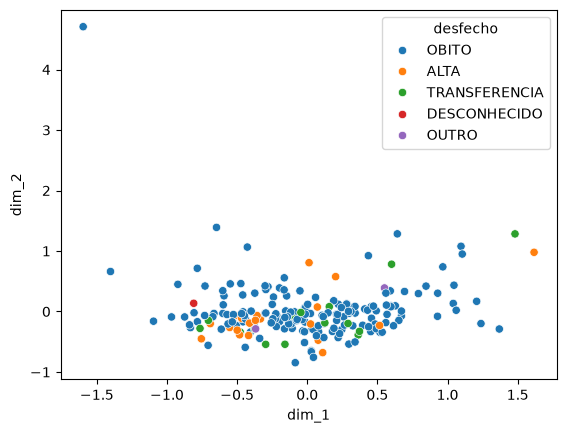

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

coords_2d = mca_result.coordinates[["dim_1", "dim_2"]]
scatter = mca_scatter_frame(df, frame, mca_result)
sns.scatterplot(data=scatter, x="dim_1", y="dim_2", hue="desfecho")
plt.show()

## Dendrograma e clusters

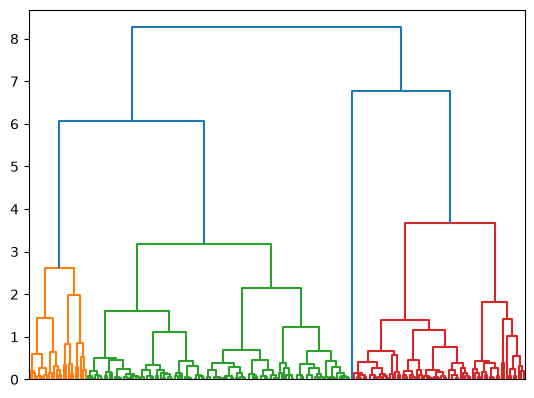

In [3]:
from scipy.cluster.hierarchy import dendrogram

linkage_matrix = hierarchical_linkage_matrix(coords_2d)
dendrogram(linkage_matrix, no_labels=True)
plt.show()

In [4]:
hierarchical_labels = fit_hierarchical_clusters(coords_2d, n_clusters=4)
kmeans_labels = fit_kmeans_on_mca(coords_2d, n_clusters=4)
pd.Series(hierarchical_labels).value_counts()

1    109
0     71
3     24
2      1
Name: count, dtype: int64